# Daily Revenue Forecasting

## Objective

The objective of this notebook is to forecast future marketplace revenue using historical daily transaction data.

Unlike monthly forecasting, daily forecasting provides substantially more observations, enabling machine learning models to capture temporal patterns more effectively.

Business Questions

- Can future daily revenue be predicted accurately?
- Which historical patterns drive revenue?
- How much revenue is expected over the next month?
- Which features contribute most to forecasting performance?

In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import plotly.express as px

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:

project_root = Path.cwd().parent.parent
DATA_DIR = project_root / "datasets" / "Olist"


In [6]:
orders = pd.read_csv(
    DATA_DIR/"olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

payments = pd.read_csv(
    DATA_DIR/"olist_order_payments_dataset.csv"
)

In [7]:
sales = (
    orders
    .merge(
        payments,
        on="order_id"
    )
)

In [8]:
# daily revenue 
daily_sales = (

    sales

    .groupby(

        sales["order_purchase_timestamp"]

        .dt.date

    )

    ["payment_value"]

    .sum()

    .reset_index()

)

daily_sales.columns=[

    "Date",

    "Revenue"

]

daily_sales["Date"]=pd.to_datetime(

    daily_sales["Date"]

)

daily_sales.head()

,Date,Revenue
0,2016-09-04,136.23
1,2016-09-05,75.06
2,2016-09-13,40.95
3,2016-10-02,109.34
4,2016-10-03,595.14


In [9]:
print(len(daily_sales))

633


In [10]:
fig = px.line(

    daily_sales,

    x="Date",

    y="Revenue",

    title="Daily Revenue",

    template="plotly_white"

)

fig.show()

In [11]:
daily_sales["Rolling7"]=(

    daily_sales["Revenue"]

    .rolling(7)

    .mean()

)

daily_sales["Rolling30"]=(

    daily_sales["Revenue"]

    .rolling(30)

    .mean()

)

In [12]:
fig=px.line(

    daily_sales,

    x="Date",

    y=[

        "Revenue",

        "Rolling7",

        "Rolling30"

    ],

    title="Daily Revenue with Rolling Means",

    template="plotly_white"

)

fig.show()

In [13]:
daily_sales["DayName"]=(

    daily_sales["Date"]

    .dt.day_name()

)

In [14]:
weekday=(

    daily_sales

    .groupby("DayName")

    ["Revenue"]

    .mean()

    .reindex([

        "Monday",

        "Tuesday",

        "Wednesday",

        "Thursday",

        "Friday",

        "Saturday",

        "Sunday"

    ])

    .reset_index()

)

fig=px.bar(

    weekday,

    x="DayName",

    y="Revenue",

    title="Average Revenue by Weekday",

    template="plotly_white"

)

fig.show()

In [15]:
daily_sales["Year"]=daily_sales["Date"].dt.year

daily_sales["Month"]=daily_sales["Date"].dt.month

daily_sales["Week"]=daily_sales["Date"].dt.isocalendar().week.astype(int)

daily_sales["Day"]=daily_sales["Date"].dt.day

daily_sales["DayOfWeek"]=daily_sales["Date"].dt.dayofweek

daily_sales["Quarter"]=daily_sales["Date"].dt.quarter

daily_sales["Weekend"]=(

    daily_sales["DayOfWeek"]>=5

).astype(int)

In [16]:
for lag in [1,2,3,7,14,30]:

    daily_sales[f"Lag_{lag}"]=daily_sales["Revenue"].shift(lag)

In [17]:
for window in [7,14,30]:

    daily_sales[f"RollingMean_{window}"]=(
        daily_sales["Revenue"]
        .rolling(window)
        .mean()
    )

    daily_sales[f"RollingStd_{window}"]=(
        daily_sales["Revenue"]
        .rolling(window)
        .std()
    )

In [18]:
daily_sales=daily_sales.dropna()

daily_sales.head()

,Date,Revenue,Rolling7,Rolling30,DayName,Year,Month,Week,Day,DayOfWeek,...,Lag_3,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingStd_7,RollingMean_14,RollingStd_14,RollingMean_30,RollingStd_30
30,2017-01-21,3094.76,3824.794286,3409.162333,Saturday,2017,1,3,21,5,...,4683.38,1507.36,1447.99,136.23,3824.794286,792.808865,2850.372857,1315.596342,3409.162333,3361.828537
31,2017-01-22,4280.22,4071.777143,3549.334333,Sunday,2017,1,3,22,6,...,4140.16,2551.34,809.63,75.06,4071.777143,567.156419,3098.272143,1225.366295,3549.334333,3305.209575
32,2017-01-23,7553.89,4620.584286,3799.765667,Monday,2017,1,4,23,0,...,4698.07,3712.24,774.51,40.95,4620.584286,1403.419423,3582.513571,1536.469394,3799.765667,3314.826305
33,2017-01-24,6794.50,5034.997143,4022.604333,Tuesday,2017,1,4,24,1,...,3094.76,3893.61,1571.17,109.34,5034.997143,1571.239864,3955.608571,1641.110134,4022.604333,3282.732301
34,2017-01-25,10434.31,5856.558571,4350.576667,Wednesday,2017,1,4,25,2,...,4280.22,4683.38,3062.33,595.14,5856.558571,2553.330202,4482.178571,2358.387882,4350.576667,3417.243756


In [19]:
split=int(len(daily_sales)*0.8)

train=daily_sales.iloc[:split]

test=daily_sales.iloc[split:]

In [20]:
features=[

    "Year",

    "Month",

    "Week",

    "Day",

    "DayOfWeek",

    "Quarter",

    "Weekend",

    "Lag_1",

    "Lag_2",

    "Lag_3",

    "Lag_7",

    "Lag_14",

    "Lag_30",

    "RollingMean_7",

    "RollingMean_14",

    "RollingMean_30",

    "RollingStd_7",

    "RollingStd_14",

    "RollingStd_30"

]

In [21]:
baseline=test["Lag_1"]

baseline_mae=mean_absolute_error(

    test["Revenue"],

    baseline

)

baseline_rmse=np.sqrt(

    mean_squared_error(

        test["Revenue"],

        baseline

    )

)

print(baseline_mae)

print(baseline_rmse)

5626.4757851239665
7553.829138457139


In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    train[features],
    train["Revenue"]
)

xgb_pred = xgb.predict(
    test[features]
)

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    test["Revenue"],
    xgb_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test["Revenue"],
        xgb_pred
    )
)

r2 = r2_score(
    test["Revenue"],
    xgb_pred
)

mape = (
    np.abs(
        (
            test["Revenue"] - xgb_pred
        ) / test["Revenue"]
    ).mean() * 100
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.3f}")

MAE  : 6729.08
RMSE : 8385.66
MAPE : 1400.93%
R²   : 0.727


In [24]:
# walk forward validation 
predictions = []
actuals = []

start = int(len(daily_sales) * 0.8)

for i in range(start, len(daily_sales)):

    train = daily_sales.iloc[:i]
    test = daily_sales.iloc[i:i+1]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    model.fit(
        train[features],
        train["Revenue"]
    )

    pred = model.predict(
        test[features]
    )[0]

    predictions.append(pred)
    actuals.append(
        test["Revenue"].values[0]
    )

In [25]:
wf_mae = mean_absolute_error(
    actuals,
    predictions
)

wf_rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

wf_r2 = r2_score(
    actuals,
    predictions
)

print("Walk Forward Results")

print(f"MAE : {wf_mae:.2f}")
print(f"RMSE : {wf_rmse:.2f}")
print(f"R² : {wf_r2:.3f}")

Walk Forward Results
MAE : 4383.03
RMSE : 5983.29
R² : 0.861


In [27]:
results = pd.DataFrame({

    "Date": daily_sales.iloc[split:]["Date"].values,

    "Actual": actuals,

    "Predicted": predictions

})

In [29]:
fig = px.line(

    results,

    x="Date",

    y=["Actual","Predicted"],

    title="Walk Forward Forecast",

    template="plotly_white"

)

fig.show()

In [30]:
results["Error"] = (
    results["Actual"]
    -
    results["Predicted"]
)

In [31]:
fig = px.histogram(

    results,

    x="Error",

    nbins=40,

    title="Prediction Error Distribution",

    template="plotly_white"

)

fig.show()

In [32]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

In [33]:
fig = px.bar(

    importance,

    x="Importance",

    y="Feature",

    orientation="h",

    title="Feature Importance",

    template="plotly_white"

)

fig.show()

In [34]:
from prophet import Prophet

prophet_df = daily_sales[
    ["Date","Revenue"]
].copy()

prophet_df.columns = [
    "ds",
    "y"
]

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_prophet.fit(
    prophet_df
)

13:54:42 - cmdstanpy - INFO - Chain [1] start processing
13:54:42 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = model_prophet.make_future_dataframe(
    periods=30
)

forecast = model_prophet.predict(
    future
)

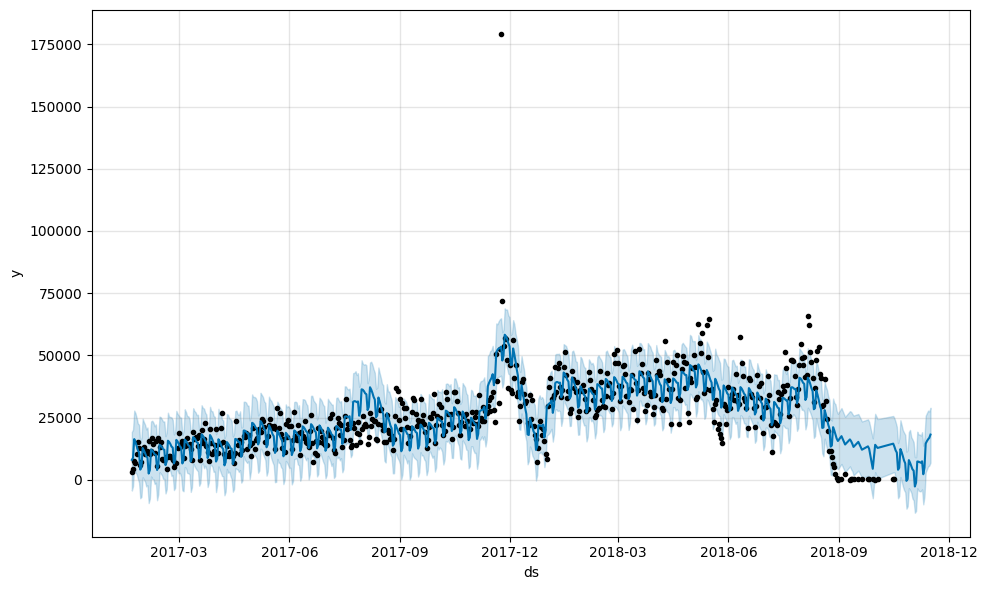

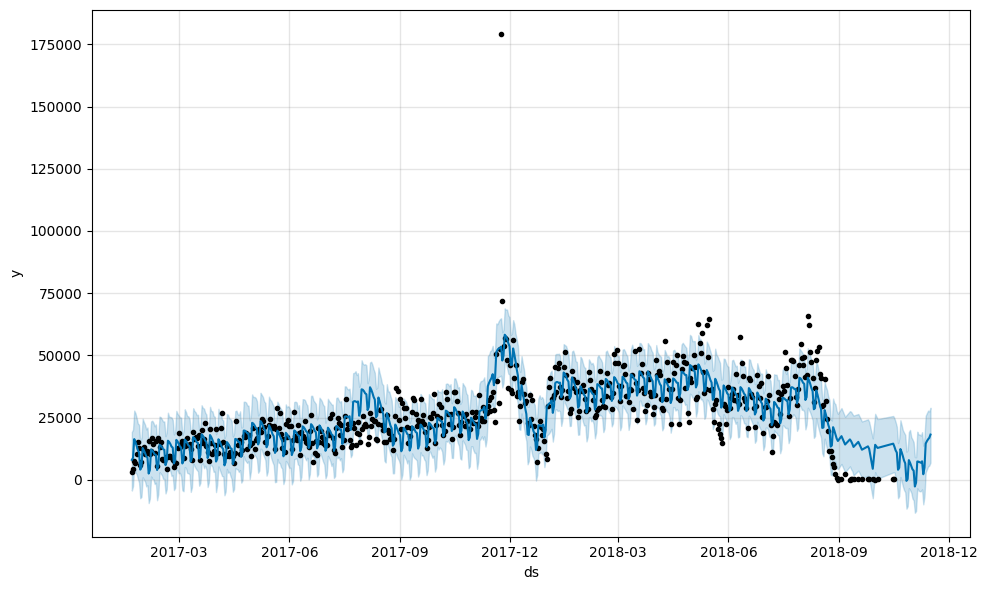

In [36]:
model_prophet.plot(
    forecast
)

In [37]:
comparison = pd.DataFrame({

    "Model":[

        "Naive",

        "XGBoost",

        "Walk Forward"

    ],

    "MAE":[

        baseline_mae,

        mae,

        wf_mae

    ],

    "RMSE":[

        baseline_rmse,

        rmse,

        wf_rmse

    ],

    "R²":[

        np.nan,

        r2,

        wf_r2

    ]

})

comparison

,Model,MAE,RMSE,R²
0,Naive,5626.475785,7553.829138,NaN
1,XGBoost,6729.075650,8385.655633,0.727460
2,Walk Forward,4383.027725,5983.292195,0.861249


In [38]:
fig = px.bar(

    comparison,

    x="Model",

    y="MAE",

    color="Model",

    title="Forecast Model Comparison",

    template="plotly_white"

)

fig.show()

In [39]:
forecast.tail(30)[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
]

,ds,yhat,yhat_lower,yhat_upper
603,2018-10-18,11794.275679,685.559767,23196.283772
604,2018-10-19,10905.594412,-861.173297,21351.258568
605,2018-10-20,3996.325627,-7460.385865,14748.850667
606,2018-10-21,4788.310118,-6625.822430,16561.563674
607,2018-10-22,12335.301466,1095.625471,23916.226379
608,2018-10-23,11097.548193,-602.621612,21983.808804
609,2018-10-24,9501.728497,-2631.665017,19932.252545
610,2018-10-25,7702.990269,-4150.031976,18935.295659
611,2018-10-26,6575.983406,-5060.597325,18060.522668
612,2018-10-27,-480.670926,-11659.139949,11281.405502


In [40]:
fig = px.line(

    forecast.tail(90),

    x="ds",

    y="yhat",

    title="Next 30-Day Revenue Forecast",

    template="plotly_white"

)

fig.show()